<a href="https://colab.research.google.com/github/aditi-tawade-ai/ML_Projects/blob/main/Customer_Segmentation/Cust_K_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem statement: A shopping mall has customer information such as age, gender, annual income, and spending score, but it does not know what types of customers it has.**

**The objective of this project is to segment customers into different groups based on their characteristics and spending behavior using the K-Means clustering algorithm.**

# Importing the libraries

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Loading Dataset

In [ ]:
path = '/content/cust_segmt.csv'
df = pd.read_csv(path)
df[:2]

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81


# Analysis of dataset

In [ ]:
df.shape

(200, 5)

we have 200 rows and 5 columns

In [ ]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
type(df)

pandas.core.frame.DataFrame

In [ ]:
df.Gender.unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


Income is available in thousand US dollers also we can observe that there are no missing values

In [ ]:
# again cross checking
df.isna().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


# Preprocessing

In [ ]:
# changing the names of columns
df = df.rename(columns={'Annual Income (k$)':'annual_income','Spending Score (1-100)':'Spend_score'})
df[:2]

,CustomerID,Gender,Age,annual_income,Spend_score
0,1,Male,19,15,39
1,2,Male,21,15,81


As we can see the column names are modified

In [ ]:
# deciding the features to use
X = df[['annual_income','Spend_score']]

we have choosed annual income and spend score as our input variables to predict clusters so no need to encode the gender catigorical column

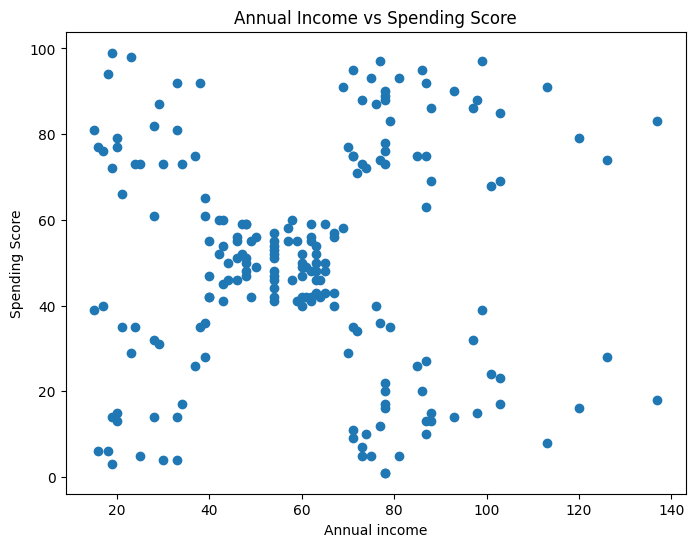

In [ ]:
# visualising before K means
plt.figure(figsize=(8,6))

plt.scatter(
    df['annual_income'],
    df['Spend_score'],

)

plt.xlabel('Annual income')
plt.ylabel('Spending Score')
plt.title('Annual Income vs Spending Score')

plt.show()

From the above graph we can predict the 5 groups or clusters lets confirm it the elbow method and silhoutte score further

In [ ]:
# scaling the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled[:2]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407]])

there is not much difference but kmeans is a distance based algorithm so it is good practice to scale the features . X_scaled contained the scaled data

# Finding the best value of k

In [ ]:
# wcss
wcss = []
from sklearn.cluster import KMeans
for i in range(1,11):
  kmeans = KMeans(n_clusters=i,random_state=42)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)
wcss

[399.99999999999994,
 273.66888662642003,
 157.70400815035939,
 109.22822707921345,
 65.56840815571681,
 60.132874871934206,
 49.668244837367965,
 37.31912287833882,
 32.495081199100916,
 30.05932269404222]

wcss - within a cluster su of squares -  it tells us how close are the points from center. Also we will check it with elbow method

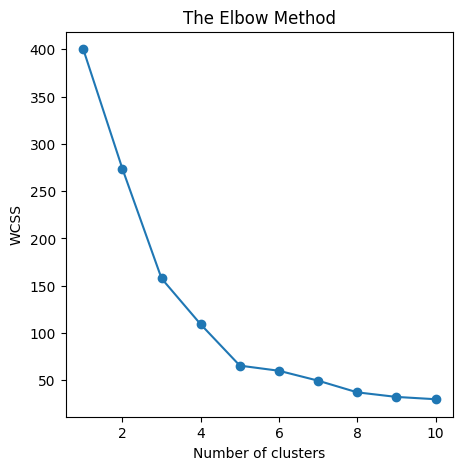

In [ ]:
# ploting elbow method
plt.figure(figsize=(5,5))
plt.plot(range(1,11),wcss,marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


We can see the sharp bend at 5 so this confirms that k=5 is best suited

In [ ]:
# checking with silhouette score aswell
from sklearn.metrics import silhouette_score
for i in range(2,11):
  kmeans = KMeans(n_clusters=i,random_state=42)
  labels = kmeans.fit_predict(X_scaled)
  score = silhouette_score(X_scaled,labels)
  print(f'Silhouette score for k={i} is {score}')

Silhouette score for k=2 is 0.3973270007887498
Silhouette score for k=3 is 0.46658474419000145
Silhouette score for k=4 is 0.49434988482196784
Silhouette score for k=5 is 0.5546571631111091
Silhouette score for k=6 is 0.5138257534676561
Silhouette score for k=7 is 0.50200146805547
Silhouette score for k=8 is 0.4550112502601921
Silhouette score for k=9 is 0.4566624374485964
Silhouette score for k=10 is 0.44475993501732874


Again the score is good for k=5 so we will fix the k value

# Creating the final k means model

Training the model

In [ ]:
kmeans = KMeans(n_clusters=5,random_state=42)
kmeans.fit(X_scaled)

KMeans(n_clusters=5, random_state=42)

Get cluster labels it tells the value present in which cluster

In [ ]:
labels = kmeans.labels_
labels

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

Adding cluster to the df

In [ ]:
df['Clusters'] = labels
df[:2]

,CustomerID,Gender,Age,annual_income,Spend_score,Clusters
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2


we need to inverse the scaled centroids to original because while plotting we are using original values of X

In [ ]:
# calculating centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

visualizing the clusters

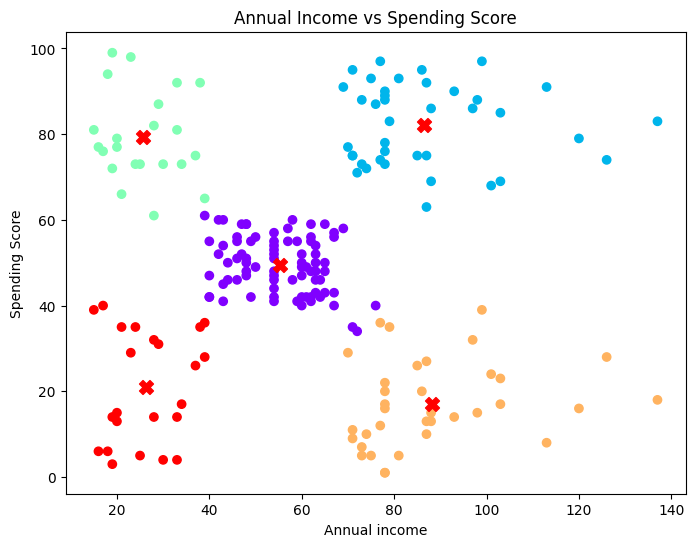

In [ ]:
plt.figure(figsize=(8,6))


plt.scatter(
    df['annual_income'],
    df['Spend_score'],
    c=df['Clusters'],
    cmap='rainbow'
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    marker='X',
    s=100,
    c='red'
)

plt.xlabel('Annual income')
plt.ylabel('Spending Score')
plt.title('Annual Income vs Spending Score')
plt.show()

Understanding the characteristics  what each cluster means

In [ ]:
df.groupby('Clusters')[['annual_income','Spend_score']].mean()

,annual_income,Spend_score
Clusters,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


from above table we can anlyse income and spend amount
1. cluster 0 - medium  ,    medium
2. cluster 1 -  high   ,     high
3. cluster 2 -  low    ,      high
4. cluster 3 -  high   ,      low
5. cluster 4 -  low    ,       low

In [ ]:
df['Clusters'].value_counts().sort_index()

,count
Clusters,
0,81
1,39
2,22
3,35
4,23


this gives the data of total customers belonging to each cluster

# save the model

In [ ]:
import pickle
with open('kmeans_model.pkl','wb') as file:
  pickle.dump(kmeans,file)

# save scaler too

In [ ]:
with open('scaler.pkl','wb') as file:
  pickle.dump(scaler,file)